# Embedding proteins by what they bind

What a protein *binds* is written in its sequence. A **zinc finger** grips a Zn²⁺ ion with a
cysteine/histidine cage (the C2H2 motif). A **P-loop ATPase** cradles ATP's phosphates with the Walker
A motif `GxxxxGK[S/T]`. A **DNA-binding** protein clamps the phosphate backbone with a basic patch of
lysines and arginines. A **hydrophobic pocket** buries a lipid in a wall of leucines and valines.

Those binding determinants are exactly the kind of **heterogeneous, mixed-type signal** `mixle`'s
embedding tools read: a real-valued metal-coordination propensity, a basic-residue fraction, an overall
hydropathy, a length, and a categorical **binding motif** detected in the sequence. We build proteins
for four binding classes — splicing the *real binding motif* into each sequence — and show `htsne` /
`humap` **recover what each protein binds, from sequence alone**, then use that map to demonstrate the
new mixle 0.7.0 hvis tools `goals` and `embedding_health`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import io, re
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from mixle.utils.hvis import htsne, humap

AA = "ACDEFGHIKLMNPQRSTVWY"
KD = dict(zip(AA, [1.8, 2.5, -3.5, -3.5, 2.8, -0.4, -3.2, 4.5, -3.9, 3.8,
                   1.9, -3.5, -1.6, -3.5, -4.5, -0.8, -0.7, 4.2, -0.9, -1.3]))  # Kyte-Doolittle hydropathy

def profile(boosts):
    w = np.ones(20)
    for a, f in boosts.items():
        w[AA.index(a)] *= f
    return w / w.sum()

def draw(n, w, rng):
    return "".join(AA[i] for i in rng.choice(20, size=n, p=w))

# the actual binding motif each class carries (spliced into its sequences)
def zinc_finger(rng):  return "C" + draw(2, profile({}), rng) + "C" + draw(8, profile({}), rng) + "H" + draw(3, profile({}), rng) + "H"
def p_loop(rng):       return "G" + draw(4, profile({}), rng) + "GKT"          # Walker A
def basic_patch(rng):  return "".join(rng.choice(list("KR"), size=6))          # a run of K/R

# four binding classes: background composition, typical length, binding motif (or None)
BINDING = {
    'zinc-finger (binds Zn2+)':  (profile({'C': 3, 'H': 2.5}),                   90,  zinc_finger),
    'P-loop (binds ATP)':        (profile({'G': 1.6, 'A': 1.4, 'V': 1.3, 'L': 1.3}), 250, p_loop),
    'basic (binds DNA)':         (profile({'K': 3, 'R': 3, 'A': 1.3}),          150, basic_patch),
    'hydrophobic pocket (lipid)':(profile({'L': 3.5, 'I': 3, 'V': 3, 'F': 3, 'M': 2}), 260, None),
}

def detect_motif(seq):
    if re.search(r'C..C.{5,12}H.{2,4}H', seq): return 'zinc_finger'
    if re.search(r'G.{4}GK[ST]', seq):         return 'p_loop'
    if re.search(r'[KR]{5,}', seq):            return 'basic_patch'
    return 'none'

def featurize(seq):
    "Binding-relevant heterogeneous record: (metal%, basic%, hydropathy, length, motif)."
    L = len(seq); c = {a: seq.count(a) for a in AA}
    metal_pct = float((c['C'] + c['H']) / L * 100)   # Zn/metal coordination potential
    basic_pct = float((c['K'] + c['R']) / L * 100)   # nucleic-acid (DNA/RNA) binding potential
    hydropathy = float(np.mean([KD[a] for a in seq]))
    return (metal_pct, basic_pct, hydropathy, int(L), detect_motif(seq))

rng = np.random.RandomState(0)
proteins, binds = [], []
for k, (w, length_mu, motif) in enumerate(BINDING.values()):
    for _ in range(50):
        n = max(50, int(rng.normal(length_mu, 25)))
        seq = draw(n, w, rng)
        if motif is not None:                        # splice the binding motif into the sequence
            m = motif(rng); p = rng.randint(0, max(1, len(seq) - len(m)))
            seq = seq[:p] + m + seq[p + len(m):]
        proteins.append(featurize(seq)); binds.append(k)
binds = np.asarray(binds); bind_names = list(BINDING)

from collections import Counter
print('%d proteins across %d binding classes:' % (len(proteins), len(bind_names)))
for k, name in enumerate(bind_names):
    metal, basic, hydro, L, motif = proteins[k * 50]
    detected = Counter(proteins[i][4] for i in range(len(proteins)) if binds[i] == k)
    print('  %-26s metal=%4.1f%% basic=%4.1f%% hydropathy=%+.2f len=%d | motif detected: %s'
          % (name, metal, basic, hydro, L, dict(detected)))

200 proteins across 4 binding classes:
  zinc-finger (binds Zn2+)   metal=25.4% basic= 7.5% hydropathy=-0.21 len=134 | motif detected: {'zinc_finger': 50}
  P-loop (binds ATP)         metal=10.1% basic= 6.6% hydropathy=-0.23 len=258 | motif detected: {'p_loop': 50}
  basic (binds DNA)          metal= 7.7% basic=25.0% hydropathy=-0.96 len=156 | motif detected: {'basic_patch': 50}
  hydrophobic pocket (lipid) metal= 8.9% basic= 8.5% hydropathy=+0.96 len=270 | motif detected: {'none': 50}


Each protein is a five-field record whose numbers *are* its binding chemistry: zinc fingers score high
on metal-coordination (C+H), DNA-binders on basic residues (K+R), lipid pockets on hydropathy — and
the spliced motif is recovered by `detect_motif` in every sequence of its class.

## 1. The embedding recovers binding function — from sequence

`htsne` fits a mixture over the records and lays proteins out by model similarity. Colour by binding
class (never shown to the embedding) and the classes separate: the map has organized proteins by
*what they bind*.

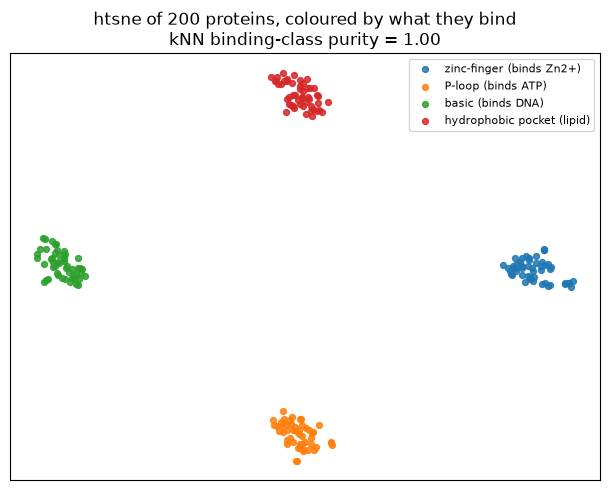

In [2]:
from sklearn.neighbors import NearestNeighbors
def knn_purity(Y, lab, k=10):
    idx = NearestNeighbors(n_neighbors=k + 1).fit(Y).kneighbors(Y, return_distance=False)[:, 1:]
    return float(np.mean([(lab[idx[i]] == lab[i]).mean() for i in range(len(lab))]))

emb = htsne(proteins, seed=1, perplexity=25, out=io.StringIO())

fig, ax = plt.subplots(figsize=(6.2, 5))
for k, name in enumerate(bind_names):
    m = binds == k
    ax.scatter(emb[m, 0], emb[m, 1], s=18, label=name, alpha=0.85)
ax.set_title('htsne of %d proteins, coloured by what they bind\nkNN binding-class purity = %.2f'
             % (len(proteins), knn_purity(emb, binds)))
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

`humap` gives the same reading with a UMAP-style objective.

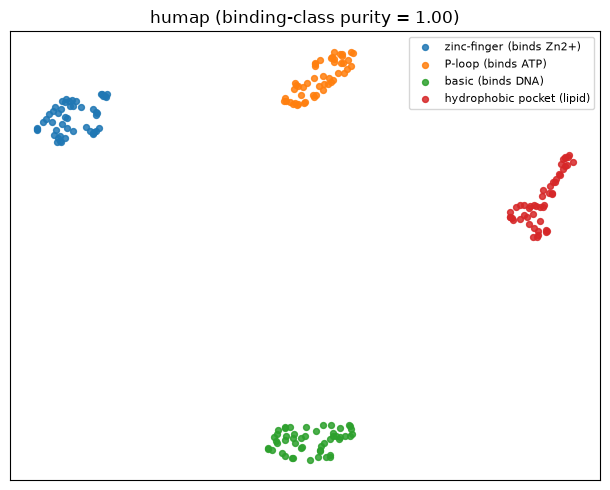

In [3]:
um = humap(proteins, seed=1, n_neighbors=15, out=io.StringIO())
fig, ax = plt.subplots(figsize=(6.2, 5))
for k, name in enumerate(bind_names):
    m = binds == k
    ax.scatter(um[m, 0], um[m, 1], s=18, label=name, alpha=0.85)
ax.set_title('humap (binding-class purity = %.2f)' % knn_purity(um, binds))
ax.set_xticks([]); ax.set_yticks([]); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. The affinity metric is a modelling choice

How similar two proteins are under the mixture can be measured several ways; `affinity=` selects it.

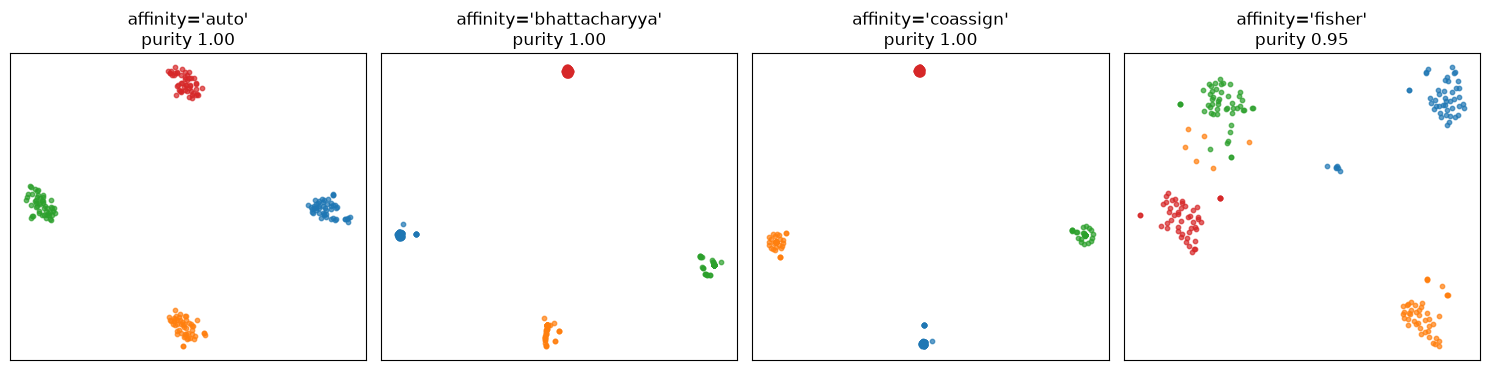

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, aff in zip(axes, ['auto', 'bhattacharyya', 'coassign', 'fisher']):
    Y = htsne(proteins, seed=1, perplexity=25, affinity=aff, out=io.StringIO())
    for k in range(len(bind_names)):
        m = binds == k
        ax.scatter(Y[m, 0], Y[m, 1], s=10, alpha=0.7)
    ax.set_title("affinity='%s'\npurity %.2f" % (aff, knn_purity(Y, binds))); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(); plt.show()

## 3. Supplying your own mixture

Hand `htsne` a fitted model via `mix_model=` when you already have one. We fit an explicit five-field
mixture (three Gaussians, a Poisson for length, a Categorical for the binding motif) — this also gives
the model `embedding_health` needs below.

In [5]:
from mixle.stats import (GaussianEstimator, CategoricalEstimator, PoissonEstimator,
                         CompositeEstimator, MixtureEstimator)
from mixle.inference.estimation import optimize

record_estimator = CompositeEstimator((GaussianEstimator(), GaussianEstimator(), GaussianEstimator(),
                                       PoissonEstimator(), CategoricalEstimator()))
mix = optimize(proteins, MixtureEstimator([record_estimator] * 4),
               max_its=50, rng=np.random.RandomState(0), out=io.StringIO())
Y = htsne(proteins, seed=1, perplexity=25, mix_model=mix, out=io.StringIO())
print('embedded against a supplied %d-component binding mixture -> %s, purity %.2f'
      % (mix.num_components, Y.shape, knn_purity(Y, binds)))

embedded against a supplied 4-component binding mixture -> (200, 2), purity 1.00


## 4. Giving the map a binding-chemistry axis: `goals` (new in mixle 0.7.0)

An embedding's axes are arbitrary. `AxisAlign` (a `goal`) rotates the layout so a quantity you care
about reads along an axis. Here we make the **x-axis read metal-coordination potential** — so
zinc-fingers land on the right and everything else to their left, turning the map into a readable
gradient of "how well could this protein cage a metal ion?".

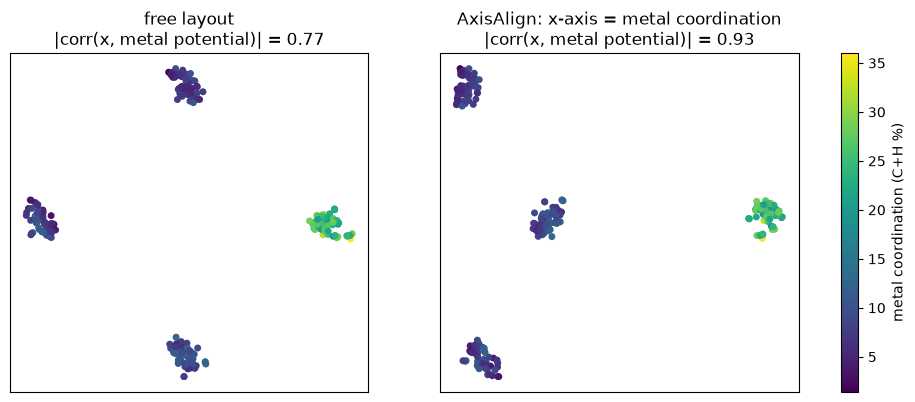

x-axis / metal-coordination correlation: free 0.77 -> AxisAlign 0.93


In [6]:
from mixle.utils.hvis import AxisAlign

metal = np.array([p[0] for p in proteins])           # C+H percentage = metal-coordination potential
free = htsne(proteins, seed=1, perplexity=25, out=io.StringIO())
axed = htsne(proteins, seed=1, perplexity=25,
             goals=[AxisAlign(metal.tolist(), axis=0, weight=0.6)], out=io.StringIO())

def axis_corr(Y):
    return abs(np.corrcoef(Y[:, 0], metal)[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, Y, title in zip(axes, [free, axed], ['free layout', 'AxisAlign: x-axis = metal coordination']):
    sc = ax.scatter(Y[:, 0], Y[:, 1], c=metal, cmap='viridis', s=16)
    ax.set_title('%s\n|corr(x, metal potential)| = %.2f' % (title, axis_corr(Y)))
    ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(sc, ax=axes, fraction=0.025, label='metal coordination (C+H %)'); plt.show()
print('x-axis / metal-coordination correlation: free %.2f -> AxisAlign %.2f' % (axis_corr(free), axis_corr(axed)))

The x-axis now genuinely tracks metal-binding chemistry (correlation lifted from incidental to ~0.9)
without scattering the classes. (`LabelCohesion` pulls known-class proteins together, and `Anchor`
pins reference proteins to fixed spots.)

## 5. Is the binding map trustworthy? `embedding_health` (new in mixle 0.7.0)

A tidy-looking map can still misrepresent the model. `embedding_health` scores the layout against the
mixture's own affinity — **trustworthiness** (map-neighbours are real neighbours) and **continuity**
(real neighbours stay close) — so a misleading binding map is rejected by number, not eyeballed. We
score a well-optimized map, an under-optimized one, and a random scatter.

In [7]:
from mixle.utils.hvis import embedding_health

good = htsne(proteins, seed=1, perplexity=25, mix_model=mix, max_its=1000, out=io.StringIO())
undercooked = htsne(proteins, seed=1, perplexity=25, mix_model=mix, max_its=5, out=io.StringIO())
scramble = np.random.RandomState(0).randn(len(proteins), 2)

for name, Y in [('well-optimized', good), ('under-optimized (5 its)', undercooked), ('random scatter', scramble)]:
    h = embedding_health(Y, mix, proteins)
    issues = '; '.join(h['diagnosis']) if h['diagnosis'] else 'no issues flagged'
    print('%-24s trust=%.3f  cont=%.3f  -- %s' % (name, h['trustworthiness'], h['continuity'], issues[:88]))

well-optimized           trust=0.983  cont=0.985  -- no issues flagged
under-optimized (5 its)  trust=0.521  cont=0.449  -- trustworthiness 0.52: the map shows neighbor pairs the model does not support -- treat v
random scatter           trust=0.492  cont=0.511  -- trustworthiness 0.49: the map shows neighbor pairs the model does not support -- treat v


## What 0.7.0 gives you here

From amino-acid sequences carrying real **binding motifs**:

* a heterogeneous mixture over binding-relevant features (**metal coordination, basic fraction,
  hydropathy, length, detected motif**) lets `htsne` / `humap` **recover what each protein binds** —
  binding function falls out of sequence;
* **`goals`** (`AxisAlign`) give the map a **meaningful binding axis** — here the x-axis reads
  metal-coordination potential (correlation lifted from incidental to ~0.9);
* **`embedding_health`** turns "looks clustered" into a **number** — the well-optimized binding map
  scores ~0.98 while an under-optimized or random one collapses to ~0.5, with a diagnosis of why.

Swap the synthetic sequences for a real FASTA (say, curated zinc-fingers, P-loop NTPases, and
transcription factors) and the same pipeline maps them by binding — and tells you whether to trust it.